# Taylor Series and Newton's Method

**Goal:** Understand how to approximate functions with polynomials (Taylor), and how to use curvature for fast optimization (Newton's method).

**Reference:** Mathematics for ML - Chapter 5.4, 7.1

## Taylor Series

Any smooth function can be approximated near a point $x_0$ by a polynomial:

$$f(x) \approx f(x_0) + f'(x_0)(x - x_0) + \frac{f''(x_0)}{2!}(x - x_0)^2 + \frac{f'''(x_0)}{3!}(x - x_0)^3 + \cdots$$

**Orders of approximation:**
- **0th order**: constant $f(x_0)$ — flat line
- **1st order**: linear $f(x_0) + f'(x_0)(x - x_0)$ — tangent line
- **2nd order**: quadratic — captures curvature
- Higher orders → more accurate locally

**Why it matters for ML:**
- Gradient descent uses **1st-order** approximation
- Newton's method uses **2nd-order** approximation
- Loss functions are locally approximated this way

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

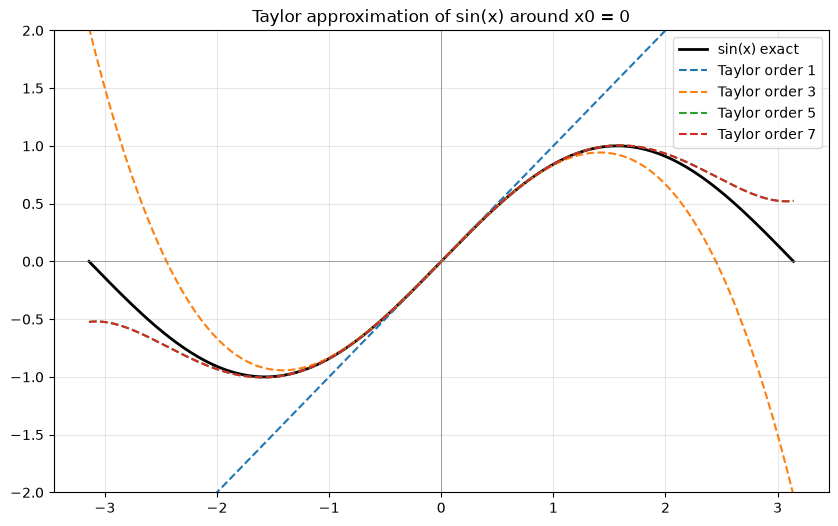

In [10]:
def taylor_sin(x, x0=0, order=1):
    """
    Taylor approximation of sin(x) around x0, up to given order.
    sin derivatives cycle: cos, -sin, -cos, sin, ...
    """
    terms = []
    if order >= 0:
        terms.append(math.sin(x0))
    if order >= 1:
        terms.append(math.cos(x0) * (x - x0))
    if order >= 2:
        terms.append(-math.sin(x0) / 2 * (x - x0)**2)
    if order >= 3:
        terms.append(-math.cos(x0) / 6 * (x - x0)**3)
    if order >= 4:
        terms.append(math.sin(x0) / 24 * (x - x0)**4)
    if order >= 5:
        terms.append(math.cos(x0) / 120 * (x - x0)**5)
    return sum(terms)


# Compare different orders
x_vals = np.linspace(-np.pi, np.pi, 200)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, np.sin(x_vals), 'k-', linewidth=2, label='sin(x) exact')

for order in [1, 3, 5, 7]:
    y_vals = [taylor_sin(x, x0=0, order=order) for x in x_vals]
    ax.plot(x_vals, y_vals, '--', label=f'Taylor order {order}')

ax.set_ylim(-2, 2)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_title('Taylor approximation of sin(x) around x0 = 0')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Taylor and Optimization

Near a point $x_t$, the loss $f$ can be approximated as:

$$f(x) \approx f(x_t) + \nabla f(x_t)^T (x - x_t) + \frac{1}{2}(x - x_t)^T H (x - x_t)$$

where $H$ is the Hessian.

**Gradient descent** only uses the first-order term.
**Newton's method** uses both, moving toward the minimum of the quadratic approximation.

**Minimum of the quadratic approx:**
$$\nabla f(x_t) + H (x - x_t) = 0 \implies x = x_t - H^{-1} \nabla f(x_t)$$

## Newton's Method

**Update rule:**

$$x_{t+1} = x_t - H^{-1} \nabla f(x_t)$$

where $H$ is the Hessian at $x_t$.

**Comparison with gradient descent:**

| Method | Update | Convergence |
|--------|--------|-------------|
| Gradient Descent | $x - \eta \nabla f$ | Linear (slow) |
| Newton's Method | $x - H^{-1} \nabla f$ | Quadratic (fast) |

**Pros:**
- Much faster near minimum
- No learning rate to tune

**Cons:**
- Requires Hessian ($O(n^2)$ memory)
- Inverting Hessian is $O(n^3)$
- Can diverge if Hessian is not positive definite

In [11]:
def numerical_gradient(f, x, h=1e-5):
    """Numerical gradient."""
    x = np.array(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        xp = x.copy(); xp[i] += h
        xm = x.copy(); xm[i] -= h
        grad[i] = (f(xp) - f(xm)) / (2 * h)
    return grad

def numerical_hessian(f, x, h=1e-4):
    """Numerical Hessian."""
    x = np.array(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            xpp = x.copy(); xpp[i] += h; xpp[j] += h
            xpm = x.copy(); xpm[i] += h; xpm[j] -= h
            xmp = x.copy(); xmp[i] -= h; xmp[j] += h
            xmm = x.copy(); xmm[i] -= h; xmm[j] -= h
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4 * h * h)
    return H

def numerical_gradient(f, x, h=1e-5):
    """Numerical gradient."""
    x = np.array(x, dtype=float)
    grad = np.zeros_like(x)
    for i in range(len(x)):
        xp = x.copy(); xp[i] += h
        xm = x.copy(); xm[i] -= h
        grad[i] = (f(xp) - f(xm)) / (2 * h)
    return grad


def numerical_hessian(f, x, h=1e-4):
    """Numerical Hessian."""
    x = np.array(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            xpp = x.copy(); xpp[i] += h; xpp[j] += h
            xpm = x.copy(); xpm[i] += h; xpm[j] -= h
            xmp = x.copy(); xmp[i] -= h; xmp[j] += h
            xmm = x.copy(); xmm[i] -= h; xmm[j] -= h
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4 * h * h)
    return H


def newton_method(f, x0, n_steps=10, tol=1e-8):
    """Minimize f using Newton's method."""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    for _ in range(n_steps):
        g = numerical_gradient(f, x)
        H = numerical_hessian(f, x)
        # Newton update: x = x - H^{-1} g
        try:
            step = np.linalg.solve(H, g)
        except np.linalg.LinAlgError:
            print("Hessian singular, stopping.")
            break
        x = x - step
        history.append(x.copy())
        if np.linalg.norm(step) < tol:
            break
    return np.array(history)


# Test: f(x, y) = x^2 + 3y^2, minimum at (0, 0)
f = lambda v: v[0]**2 + 3 * v[1]**2

history_newton = newton_method(f, x0=[3.0, 3.0], n_steps=10)
print("Newton's method:")
for i, p in enumerate(history_newton):
    print(f"  Step {i}: {p}, f = {f(p):.6e}")


Newton's method:
  Step 0: [3. 3.], f = 3.600000e+01
  Step 1: [-1.82964750e-08 -1.82372637e-08], f = 1.332554e-15
  Step 2: [-1.55509955e-22  2.61389074e-22], f = 2.291561e-43
  Step 3: [-1.55509955e-22  2.61389074e-22], f = 2.291561e-43


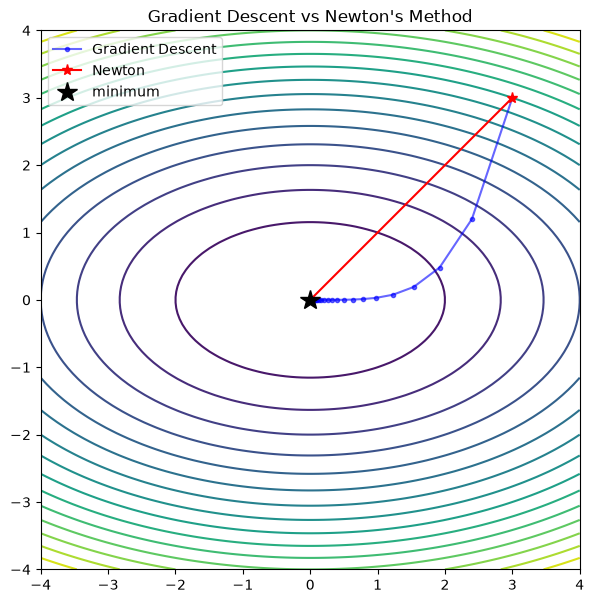

GD final:     [3.45876451e-02 3.29853482e-08], f = 1.196305e-03
Newton final: [-1.55509955e-22  2.61389074e-22], f = 2.291561e-43


In [12]:
def gradient_descent(f, x0, lr=0.1, n_steps=20):
    """Plain gradient descent."""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    for _ in range(n_steps):
        g = numerical_gradient(f, x)
        x = x - lr * g
        history.append(x.copy())
    return np.array(history)

history_gd = gradient_descent(f, x0=[3.0, 3.0], lr=0.1, n_steps=20)
history_newton = newton_method(f, x0=[3.0, 3.0], n_steps=10)

fig, ax = plt.subplots(figsize=(7, 7))

x_vals = np.linspace(-4, 4, 100)
y_vals = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = X**2 + 3 * Y**2
ax.contour(X, Y, Z, levels=20, cmap='viridis')

ax.plot(history_gd[:, 0], history_gd[:, 1], 'b.-', label='Gradient Descent', alpha=0.6)
ax.plot(history_newton[:, 0], history_newton[:, 1], 'r*-', label='Newton', markersize=8)
ax.plot(0, 0, 'k*', markersize=15, label='minimum')

ax.set_title('Gradient Descent vs Newton\'s Method')
ax.legend()
ax.set_aspect('equal')
plt.show()

print(f"GD final:     {history_gd[-1]}, f = {f(history_gd[-1]):.6e}")
print(f"Newton final: {history_newton[-1]}, f = {f(history_newton[-1]):.6e}")

## Limitations of Newton's Method

1. **Hessian not positive definite** → step may go uphill
2. **Expensive:** $O(n^3)$ to invert for $n$ parameters
3. **Memory:** $O(n^2)$ to store Hessian



**Solutions in practice:**
- **Quasi-Newton methods (BFGS, L-BFGS):** approximate Hessian
- **Adam, RMSprop:** use only gradient, but with adaptive learning rates
- **Natural gradient:** uses Fisher information instead of Hessian

## Key Takeaways

- **Taylor series** approximates functions locally with polynomials
- **1st order Taylor** → gradient descent
- **2nd order Taylor** → Newton's method
- **Newton update:** $x_{t+1} = x_t - H^{-1} \nabla f(x_t)$
- **Quadratic convergence** near minimum, but expensive per step
- **In ML:** L-BFGS for small models, Adam for large ones

## Connection to ML

- Gradient descent is 1st-order Taylor optimization
- Newton's method is 2nd-order
- Adam approximates 2nd-order behavior without Hessian
- Understanding Taylor explains *why* learning rate matters